# Figure: LD1 — what the main individuality axis is

Panels only; the analyses live elsewhere.

| panel | what | source |
|---|---|---|
| A | mice in the LD1–LD2 plane (mouse means ± SEM, sessions underneath), coloured by LD1 | `4_mice/lda_shrinkage.ipynb` (Mice in the LDA space) |
| B | syllable use along LD1: per-bin correlation of each syllable with LD1 across sessions, against a permutation null | `4_mice/lda_shrinkage.ipynb` (structural coefficients) |
| C | trial-level correlates of LD1 (6 measures; signed choice bias dropped) | `4_mice/LDA_behavior.ipynb` |
| D | repeatability vs single-measure mouse identification, task measures and LD1–3 | `non_emerging/session_metric_individuality.ipynb` Part 3 |
| E | mouse identification from syllables vs from task measures | `non_emerging/session_metric_individuality.ipynb` Part 3 |

Each panel is a `draw_X(fig, spec)` function; the last cell assembles them into one 180 mm figure (same type size everywhere) and writes `figure_generation/figures/fig_ld1.pdf` (for LaTeX) and a dated SVG.

In [1]:
import sys, pathlib, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
PI = REPO / 'paper-individuality'
for p in [PI, PI / 'learning_individuality', PI / '4_mice']:
    sys.path.insert(0, str(p))
import paper_style as ps
import lda_shrinkage_core as lsc
from session_filters import exclusions_by_timepoint
ps.use('paper')
ps.use_paw_states('uniform')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters

In [2]:
FIG = 'fig_ld1'
LDA_FILE = PI / 'clustering' / 'data_files' / 'mouse_LDA_5_bins_raw_shrink0.5_wmouse_360_02-10-2026'
SYLLABLE_FILE = PI / 'data' / '8_k_10_bin_syllables_02-10-2026'      # the file the LDA was fit on
TRIAL_META = PI / 'data' / 'session_trial_meta_19-08-2026'             # LDA_behavior's trial file
TRAINING_FILE = REPO / 'learning_prediction' / 'training_time_05-05-2026'
# newest session-metric table written by non_emerging/session_metric_individuality.ipynb
NONEMERGING_METRICS = sorted(glob.glob(str(PI / 'non_emerging' / 'nonemerging_session_metrics_*.csv')),
                             key=lambda f: pd.to_datetime(re.search(r'(\d\d-\d\d-\d{4})', f).group(1), dayfirst=True))[-1]
QC_STRICTNESS = 'filtered_out'
N_PERMS = 1000              # B: permutation null for the per-bin correlations
MIN_SESSIONS_WITHIN = 2     # D/E: a mouse needs another session to be identified / to have within-mouse variance
ID_MAX_MISSING = 0.05       # D/E: a task measure missing in more sessions than this leaves the feature vector
EXCLUDE_SINGLE = {'p_eng_to_dis', 'p_engaged', 'p_dis_to_eng'}   # D: as session_metric_individuality
ID_SHRINKAGE = 0.1          # task measures (session_metric_individuality)
SYLLABLE_SHRINKAGE = 0.5    # syllables (fixed, as session_metric_individuality)
ID_REPEATS = 5
N_PER_MOUSE = 3
SEED = 0
print('non-emerging metrics:', pathlib.Path(NONEMERGING_METRICS).name)

non-emerging metrics: nonemerging_session_metrics_29-09-2026.csv


## Data

The LD coordinates are the saved embedding (mouse-weighted shrinkage LDA, 260 sessions, 56 mice). An axis's share of between-mouse variance is the variance of the mouse means along it over the sum across all axes — the definition `lda_shrinkage` labels its axes with.

In [3]:
lda = pd.read_pickle(LDA_FILE)
n_axes = sum(isinstance(c, (int, np.integer)) for c in lda.columns)
mouse_means_all = lda.groupby('mouse_name')[list(range(n_axes))].mean()
between_var = mouse_means_all.var(axis=0, ddof=0).to_numpy()
AXIS_SHARE = between_var / between_var.sum()
lda = lda.rename(columns={0: 'LD1', 1: 'LD2', 2: 'LD3'})
print(f"{len(lda)} sessions, {lda['mouse_name'].nunique()} mice; between-mouse share LD1-3: {np.round(AXIS_SHARE[:3], 3)}")

260 sessions, 56 mice; between-mouse share LD1-3: [0.136 0.099 0.085]


## Panel A — mice in the LD1–LD2 plane

Mouse means ± SEM (the mouse's own session count), sessions as small dots in the mouse's colour; colour = mouse-mean LD1. No mouse names.

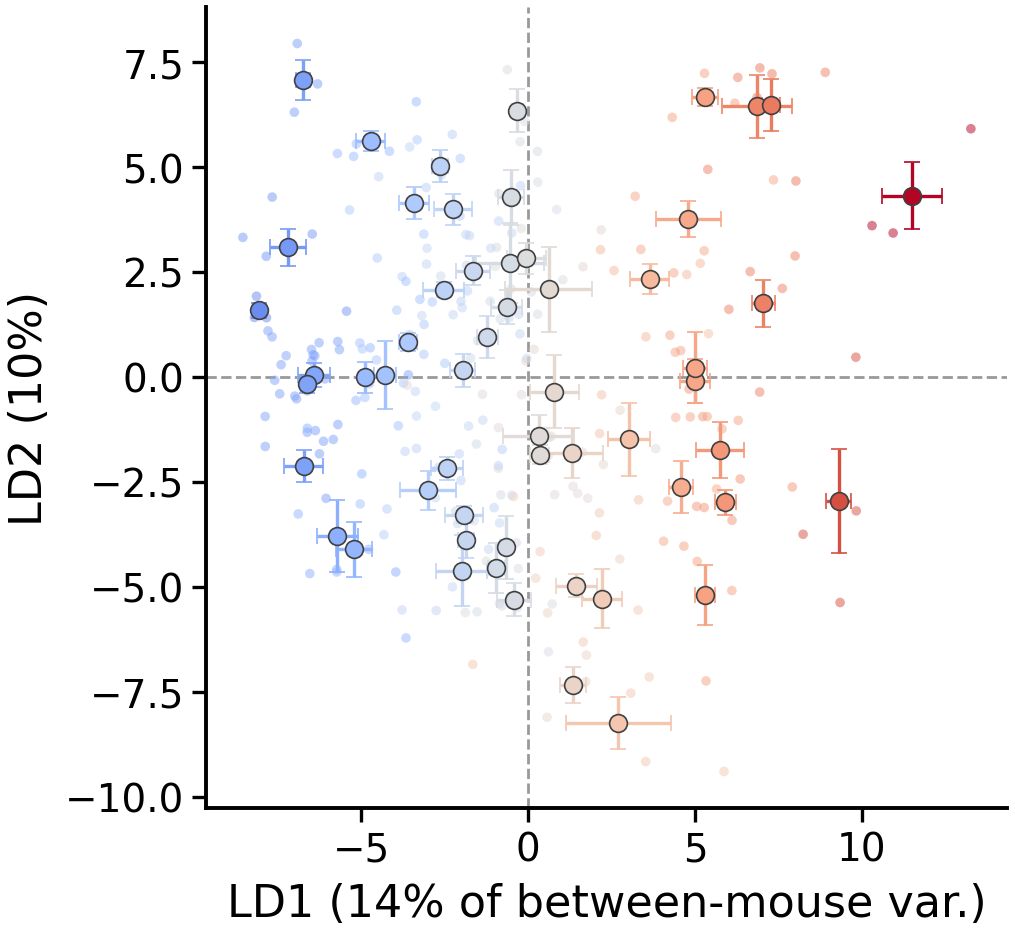

In [4]:
def draw_A(fig, spec, square=True):
    ax = fig.add_subplot(spec)
    g = lda.groupby('mouse_name')
    mm, se = g[['LD1', 'LD2']].mean(), g[['LD1', 'LD2']].std().div(np.sqrt(g.size()), axis=0)
    col = dict(zip(mm.index, ps.ld1_colors(mm['LD1'].to_numpy())))
    ax.scatter(lda['LD1'], lda['LD2'], c=[col[m] for m in lda['mouse_name']], s=3, alpha=0.5, lw=0, zorder=1)
    for m in mm.index:
        ax.errorbar(mm.loc[m, 'LD1'], mm.loc[m, 'LD2'], xerr=se.loc[m, 'LD1'], yerr=se.loc[m, 'LD2'], fmt='o',
                    ms=3.2, color=col[m], ecolor=col[m], elinewidth=0.6, mec='0.25', mew=0.3, zorder=2)
    for f in (ax.axvline, ax.axhline):
        f(0, color='0.6', ls='--', lw=0.5, zorder=0)
    if square:
        ax.set_box_aspect(1)
    ax.set_xlabel(f'LD1 ({100 * AXIS_SHARE[0]:.0f}% of between-mouse var.)')
    ax.set_ylabel(f'LD2 ({100 * AXIS_SHARE[1]:.0f}%)')
    return [ax]

fig = plt.figure(figsize=(2.6, 2.6)); draw_A(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel B — syllable use along LD1

For every trial bin (4 epochs × 10) and syllable (8 paw states, whisking, licking): the correlation, across the 260 LDA sessions, between the session's occupancy of that syllable in that bin and the session's LD1. Grey band = 95% of the same correlation with LD1 permuted across sessions (one band per panel, the envelope over syllables); traces are solid where they leave it. As in `lda_shrinkage`, sessions are the unit, so the band is somewhat narrow (sessions of one mouse are not independent).

Paw states are in the uniform (vigor) numbering, as in the engagement figure — the stored relabelling is undone with `ps.paw_codes`; this changes names and colours, not correlations.

260 sessions x 40 bins x 10 syllables


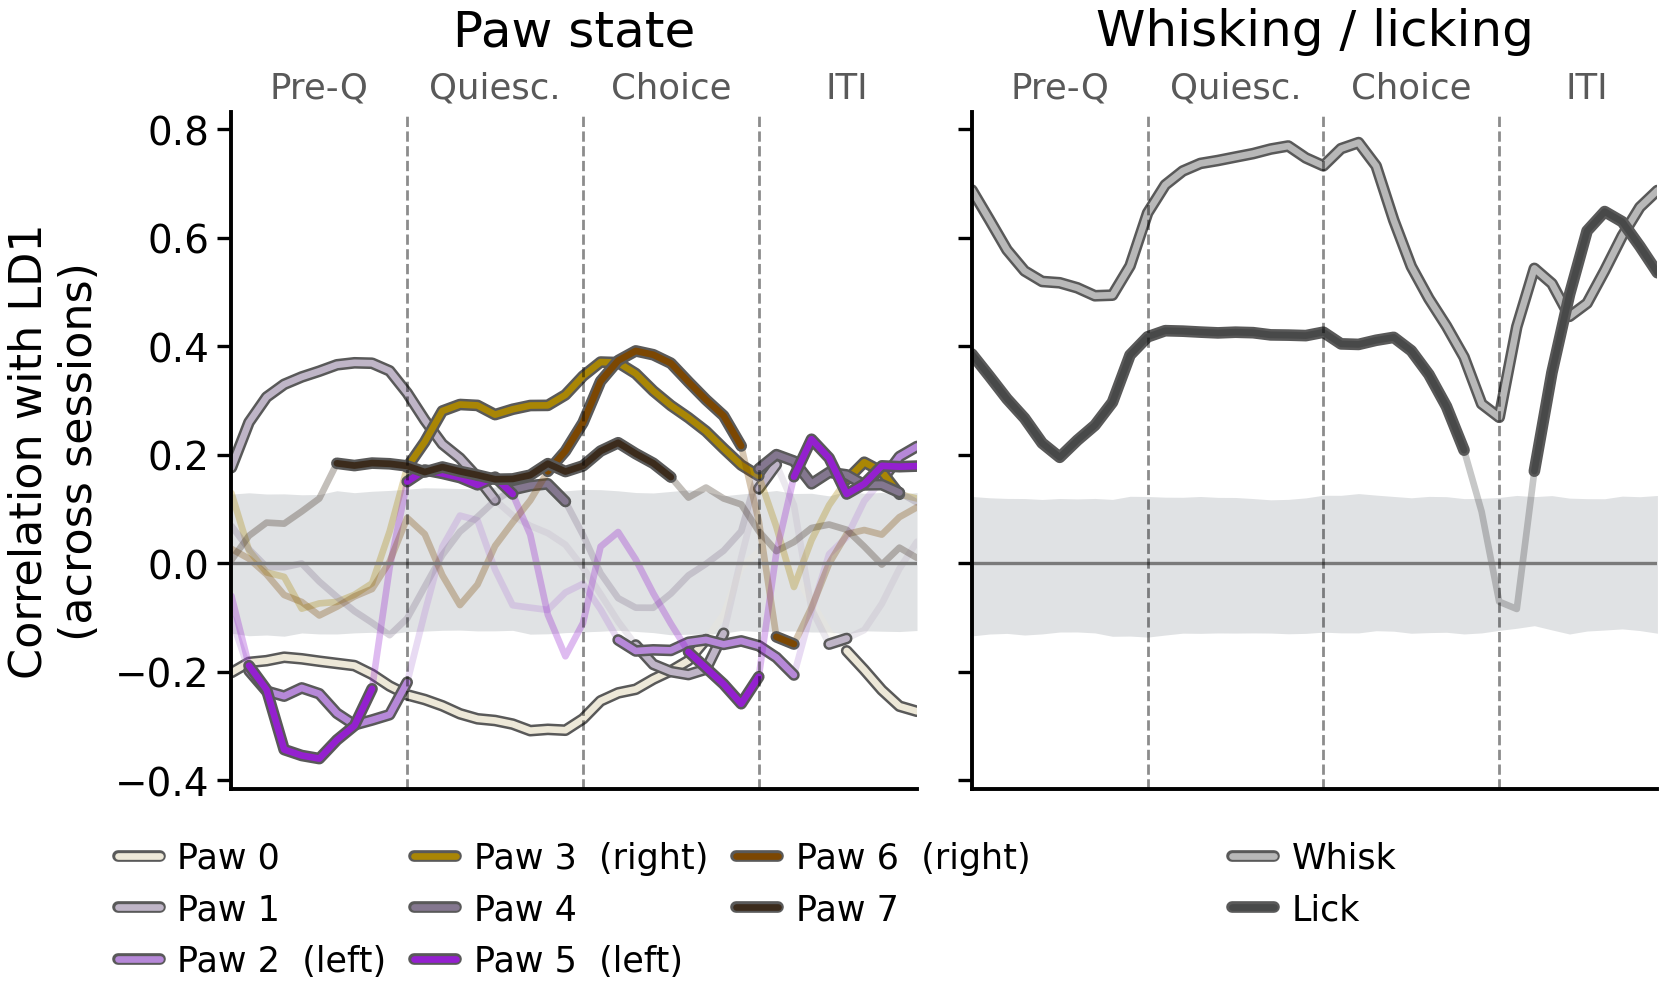

In [5]:
syl = pd.read_parquet(SYLLABLE_FILE)
syl['session'] = syl['sample'].str[:36]
syl = syl[syl['session'].isin(lda['session'])]
EPOCHS = ps.EPOCH_NAMES
trials = (syl.pivot(index=['mouse_name', 'session', 'sample'], columns='broader_label', values='binned_sequence')
          .reset_index().dropna(subset=EPOCHS))
codes = ps.paw_codes(np.vstack([np.hstack(r) for r in trials[EPOCHS].to_numpy()]).astype(float))
paw, whisk, lick = ps.decode_syllables(codes)
OCC = np.stack([np.where(np.isnan(paw), np.nan, paw == k) for k in range(ps.N_PAW_STATES)] + [whisk, lick], axis=-1)
sess_idx = trials['session'].to_numpy()
order = lda['session'].to_numpy()
with np.errstate(invalid='ignore'):
    SESS_OCC = np.stack([np.nanmean(OCC[sess_idx == s], axis=0) for s in order])   # (sessions, 40, 10)
N_BINS = SESS_OCC.shape[1]
FEAT_LABEL = [ps.paw_label(k) for k in range(ps.N_PAW_STATES)] + ['Whisk', 'Lick']   # as fig_segmentation
FEAT_COLORS = ps.SYLLABLE_COLORS
print(f'{len(order)} sessions x {N_BINS} bins x {SESS_OCC.shape[2]} syllables')

def colwise_r(Mx, v):
    Mc = Mx - np.nanmean(Mx, axis=0)
    Mc = np.nan_to_num(Mc)
    vc = v - v.mean()
    return (Mc.T @ vc) / (np.sqrt((Mc ** 2).sum(axis=0)) * np.sqrt((vc ** 2).sum()))

ld1 = lda['LD1'].to_numpy()
flat = SESS_OCC.reshape(len(order), -1)
STRUCT = colwise_r(flat, ld1).reshape(N_BINS, -1)
rng = np.random.default_rng(SEED)
null = np.stack([colwise_r(flat, rng.permutation(ld1)).reshape(N_BINS, -1) for _ in range(N_PERMS)])
NULL_LO, NULL_HI = np.nanpercentile(null, [2.5, 97.5], axis=0)

import matplotlib.patheffects as pe
OUTLINE = [pe.Stroke(linewidth=plt.rcParams['lines.linewidth'] + 0.9, foreground='0.35'), pe.Normal()]

def draw_B(fig, spec, legend=True):
    g = spec.subgridspec(1, 2, wspace=0.08)
    ax_p = fig.add_subplot(g[0]); ax_w = fig.add_subplot(g[1], sharey=ax_p)
    x = np.arange(N_BINS)
    for ax, feats in [(ax_p, range(ps.N_PAW_STATES)), (ax_w, [8, 9])]:
        feats = list(feats)
        ax.fill_between(x, NULL_LO[:, feats].min(1), NULL_HI[:, feats].max(1), color=ps.NULL_BAND, alpha=0.3, lw=0)
        for f in feats:
            y = STRUCT[:, f]
            ax.plot(x, y, color=FEAT_COLORS[f], alpha=0.3)
            ax.plot(x, np.where((y >= NULL_LO[:, f]) & (y <= NULL_HI[:, f]), np.nan, y), color=FEAT_COLORS[f],
                    label=FEAT_LABEL[f], path_effects=OUTLINE)
        ax.axhline(0, color=ps.NEUTRAL, lw=0.6)
        ps.epoch_lines(ax, N_BINS, label=True, names=ps.EPOCH_SHORT)
        ax.set_xlim(0, N_BINS - 1); ax.set_xticks([])
    ax_w.tick_params(labelleft=False)
    ax_p.set_ylabel('Correlation with LD1\n(across sessions)')
    ax_p.set_title('Paw state', pad=12); ax_w.set_title('Whisking / licking', pad=12)
    if legend:
        kw = dict(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.04),
                  fontsize=plt.rcParams['legend.fontsize'] * 0.9, handlelength=1.2, columnspacing=0.8)
        ax_p.legend(ncol=3, **kw); ax_w.legend(ncol=1, **kw)
    return [ax_p, ax_w]

fig = plt.figure(figsize=(4.6, 2.2)); draw_B(fig, fig.add_gridspec(1, 1)[0]); plt.show()

## Panel C — trial-level correlates of LD1

`LDA_behavior.ipynb`'s session summaries, unchanged: accuracy on easy trials (|contrast| > 0.5), |choice bias| (right-choice rate beyond what the stimuli call for, non-zero contrasts), block bias shift (0% contrast, 0.8 − 0.2 block), log median reaction time and trial elongation, log training time (mice whose log training time is exactly 0 or 1 excluded, as there). Signed choice bias is dropped, so the FDR (Benjamini–Hochberg) is over these 6. Pearson, sessions as points; a line only where FDR-significant.

      variable       r      p   n      q  significant
       correct  0.1841 0.0046 236 0.0091         True
   choice_bias -0.2242 0.0005 236 0.0016         True
          bias -0.0440 0.5010 236 0.5010        False
  log_reaction -0.3463 0.0000 235 0.0000         True
log_elongation  0.0574 0.3803 236 0.4564        False
  log_training -0.3436 0.0110  54 0.0164         True


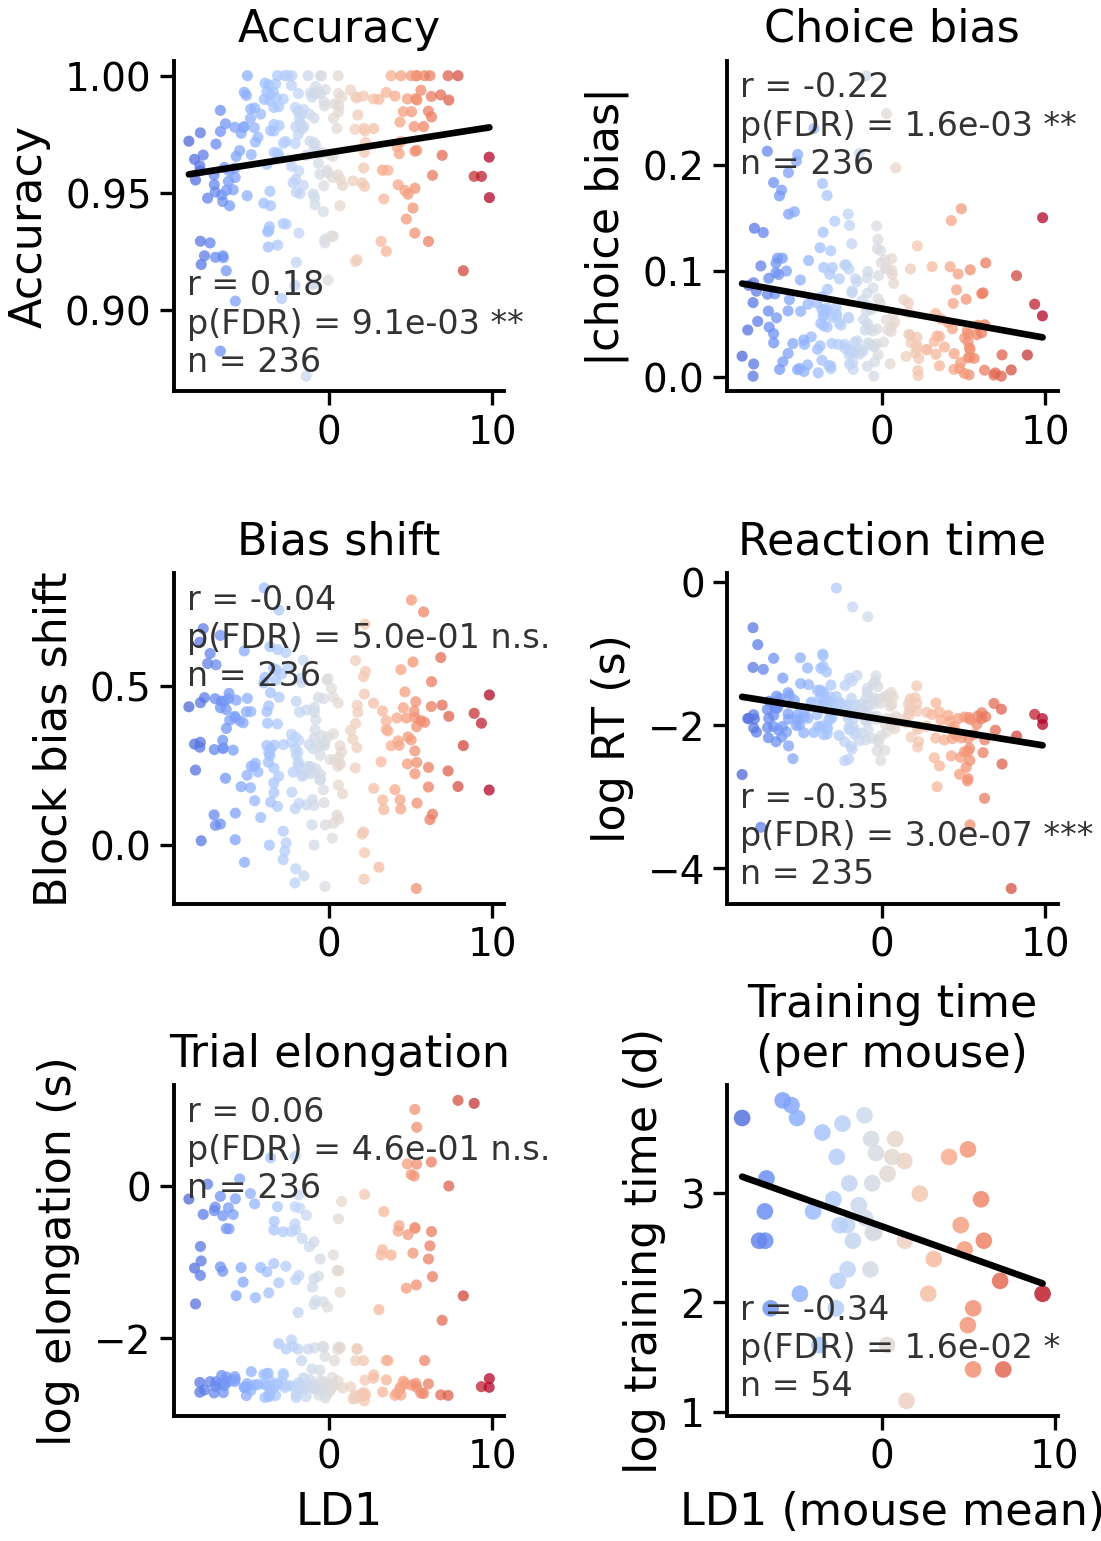

In [6]:
tf = pd.read_parquet(TRIAL_META)
tt = pd.read_parquet(TRAINING_FILE)
tt['log_training'] = np.log(tt['training_days'])
excluded = tt.loc[tt['log_training'].isin([0, 1]), 'mouse_name'].tolist()
tt = tt[~tt['mouse_name'].isin(excluded)]
tf = tf[~tf['mouse_name'].isin(excluded)].copy()
tf['choice'] = tf['choice'].map({'left': 0, 'right': 1, 'nan': np.nan})
tf['correct'] = (tf['feedback'] == 'correct').astype(int)
zc = tf[tf['contrast'] == 0].groupby(['session', 'block'])['choice'].mean().unstack('block')
bias_df = pd.DataFrame({'session': zc.index, 'bias': (zc[0.8] - zc[0.2]).values})
hc = tf[tf['contrast'] > 0].copy()
hc['expected_right'] = (hc['signed_contrast'] < 0).astype(int)
cb = hc.groupby('session').agg(choice_mean=('choice', 'mean'), expected_right_mean=('expected_right', 'mean')).reset_index()
cb['choice_bias'] = (cb['choice_mean'] - cb['expected_right_mean']).abs()
acc = tf[tf['contrast'] > 0.5].groupby('session')['correct'].mean().rename('correct').reset_index()
ss = tf.groupby(['session', 'mouse_name']).agg(reaction=('reaction', 'median'), elongation=('elongation', 'median')).reset_index()
with np.errstate(invalid='ignore'):
    ss['log_reaction'], ss['log_elongation'] = np.log(ss['reaction']), np.log(ss['elongation'])
beh = (ss.merge(bias_df, on='session').merge(cb[['session', 'choice_bias']], on='session').merge(acc, on='session')
         .merge(tt[['mouse_name', 'log_training']], on='mouse_name')
         .merge(lda[['session', 'mouse_name', 'LD1']], on=['session', 'mouse_name']))

C_VARS = [('correct', 'Accuracy', 'Accuracy'),
          ('choice_bias', 'Choice bias', '|choice bias|'),
          ('bias', 'Bias shift', 'Block bias shift'),
          ('log_reaction', 'Reaction time', 'log RT (s)'),
          ('log_elongation', 'Trial elongation', 'log elongation (s)'),
          ('log_training', 'Training time', 'log training time (d)')]
# training time is one value per MOUSE, so it is correlated at the mouse level (mouse-mean LD1); the
# other five are per-session measures, correlated across sessions. FDR (Benjamini-Hochberg) over the six.
C_PANEL_TITLE = {'log_training': 'Training time\n(per mouse)'}
beh_mouse = beh.groupby('mouse_name').agg(LD1=('LD1', 'mean'), log_training=('log_training', 'first')).reset_index()
def c_data(v):
    d = beh_mouse if v == 'log_training' else beh
    return d[['LD1', v]].replace([np.inf, -np.inf], np.nan).dropna()
rows = []
for v, *_ in C_VARS:
    d = c_data(v)
    r, p = pearsonr(d['LD1'], d[v]); rows.append(dict(variable=v, r=r, p=p, n=len(d)))
C_STATS = pd.DataFrame(rows)
C_STATS['q'] = multipletests(C_STATS['p'], method='fdr_bh')[1]
C_STATS['significant'] = C_STATS['q'] < 0.05
print(C_STATS.round(4).to_string(index=False))

import fig_layout as fl
def draw_C(fig, spec):
    g = spec.subgridspec(3, 2, wspace=0.6, hspace=0.55)
    axes, ld_all = [], beh['LD1'].to_numpy(float)
    for i, (v, title, ylab) in enumerate(C_VARS):
        ax = fig.add_subplot(g[i // 2, i % 2]); axes.append(ax)
        d = c_data(v)
        st = C_STATS.set_index('variable').loc[v]
        per_mouse = v == 'log_training'
        ax.scatter(d['LD1'], d[v], s=9 if per_mouse else 4, lw=0, alpha=0.85 if per_mouse else 0.75,
                   color=ps.LD1_CMAP(ps.ld1_norm(ld_all)(d['LD1'].to_numpy())))
        ps.regline(ax, d['LD1'].to_numpy(), d[v].to_numpy(), st['significant'])
        ax.set_box_aspect(1)
        ax.set_title(C_PANEL_TITLE.get(v, title), fontsize=plt.rcParams['font.size'])
        ax.set_ylabel(ylab)
        ax.set_xlabel(('LD1 (mouse mean)' if per_mouse else 'LD1') if i >= 4 else '')
        fl.stats_auto(ax, d['LD1'], d[v], st['r'], st['p'], int(st['n']), q=st['q'])
    return axes

fig = plt.figure(figsize=(2.9, 4.4)); draw_C(fig, fig.add_gridspec(1, 1)[0]); plt.show()


## Panels D and E — how identifiable is a mouse from its task measures vs its syllables?

The session-level task measures are the table `session_metric_individuality.ipynb` writes (`nonemerging_session_metrics_<date>.csv`, newest on disk), with LD1–3 taken from the LDA file above. Same protocol as that notebook's Part 3: leave-one-session-out mouse identification with a shrinkage LDA trained on at most `N_PER_MOUSE` sessions per mouse, fixed shrinkage, mice with ≥ `MIN_SESSIONS_WITHIN` sessions, measures z-scored.

* **D** — for each single measure (and each LD axis), repeatability R (one-way ANOVA ICC, the unbiased estimator of that notebook; point estimate only) against single-measure identification accuracy (one repeat). LD axes are open markers: they were fit to separate these mice, so neither coordinate is out-of-sample. The correlation is over the task measures only.
* **E** — identification from the vector of task measures, from the same sessions' 360 syllable features (the LDA's own feature matrix), and from the task measures with mouse labels shuffled. Mean ± SD over `ID_REPEATS` training draws.

In [7]:
M = pd.read_csv(NONEMERGING_METRICS).set_index('session')
M = M.drop(columns=[c for c in ['LD1', 'LD2', 'LD3'] if c in M]).join(lda.set_index('session')[['LD1', 'LD2', 'LD3']], how='left')
TASK = {'correct': 'Accuracy', 'log_reaction': 'Reaction time', 'log_elongation': 'Trial elongation',
        'bias': 'Block bias shift', 'signed_choice_bias': 'Choice bias (signed)', 'choice_bias': 'Choice bias (|.|)',
        'p_engaged': 'P(engaged)', 'p_switch': 'Engagement switches', 'p_eng_to_dis': 'P(eng.→dis.)',
        'p_dis_to_eng': 'P(dis.→eng.)', 'trial_count': 'Trials completed'}
TASK = {k: v for k, v in TASK.items() if k in M}
LDS = ['LD1', 'LD2', 'LD3']

def icc_oneway(values, groups):
    # unbiased one-way ANOVA repeatability (session_metric_individuality.icc_oneway)
    v = np.asarray(values, float); ok = np.isfinite(v); v = v[ok]
    g = pd.factorize(np.asarray(groups)[ok])[0]
    M_, N_ = g.max() + 1, len(v)
    n = np.bincount(g).astype(float); mu = np.bincount(g, weights=v) / n
    ms_w = ((v - mu[g]) ** 2).sum() / (N_ - M_)
    ms_b = (n * (mu - v.mean()) ** 2).sum() / (M_ - 1)
    n0 = (N_ - (n ** 2).sum() / N_) / (M_ - 1)
    s2 = (ms_b - ms_w) / n0
    return max(s2, 0) / (max(s2, 0) + ms_w)

def balanced_draw(y_sub, rng, cap=N_PER_MOUSE):
    idx = []
    for m in np.unique(y_sub):
        w = np.where(y_sub == m)[0]
        idx.extend(rng.choice(w, min(cap, len(w)), replace=False))
    return np.array(idx)

def loso_identification(X, y, shrinkage, n_repeats=ID_REPEATS, seed=SEED, shuffle=False):
    # leave-one-session-out mouse identification (session_metric_individuality.loso_identification)
    scores = []
    for rep in range(n_repeats):
        rng = np.random.default_rng(seed + rep)
        y_use = rng.permutation(y) if shuffle else y
        hit = np.empty(len(X), dtype=bool)
        for i in range(len(X)):
            rest = np.setdiff1d(np.arange(len(X)), i)
            tr = rest[balanced_draw(y_use[rest], rng)]
            k = len(np.unique(y_use[tr]))
            mdl = LinearDiscriminantAnalysis(solver='eigen', shrinkage=shrinkage, priors=np.ones(k) / k).fit(X[tr], y_use[tr])
            hit[i] = mdl.predict(X[i:i + 1])[0] == y_use[i]
        scores.append(hit.mean())
    return np.array(scores)

# one shared row set: task measures complete, an LD value, and >= MIN_SESSIONS_WITHIN sessions per mouse
id_feats = [m for m in TASK if M[m].isna().mean() <= ID_MAX_MISSING]
print('dropped for missing values:', [m for m in TASK if m not in id_feats])
sub = M[id_feats + LDS + ['mouse_name']].dropna()
n_per = sub['mouse_name'].value_counts()
sub = sub[sub['mouse_name'].isin(n_per[n_per >= MIN_SESSIONS_WITHIN].index)]
y_all = pd.factorize(sub['mouse_name'])[0]
CHANCE = 1 / len(np.unique(y_all))
z = lambda A: ((A - A.mean()) / A.std()).to_numpy(float)
print(f'{len(sub)} sessions, {len(np.unique(y_all))} mice; chance = {CHANCE:.3f}')

# D: the measures of panel C (training time is one value per mouse, so it has no repeatability) + LD1, LD2,
# labelled exactly as in C. D_CHOICE_BIAS picks the magnitude (as in C) or the signed version.
D_CHOICE_BIAS = 'choice_bias'          # or 'signed_choice_bias'
C_TITLE = {v: t for v, t, _ in C_VARS}
D_MEASURES = {'correct': C_TITLE['correct'], D_CHOICE_BIAS: C_TITLE['choice_bias'] + (' (signed)' if 'signed' in D_CHOICE_BIAS else ''),
              'bias': C_TITLE['bias'], 'log_reaction': C_TITLE['log_reaction'], 'log_elongation': C_TITLE['log_elongation'],
              'LD1': 'LD1', 'LD2': 'LD2'}
single = list(D_MEASURES)
# the identification loops refit an LDA per held-out session (~10 min in all), so results are cached;
# delete figure_generation/cache/fig_ld1_* to recompute
CACHE = PI / 'figure_generation' / 'cache'; CACHE.mkdir(exist_ok=True)
_d_cache = CACHE / f"fig_ld1_D_{pathlib.Path(NONEMERGING_METRICS).stem}_{D_CHOICE_BIAS}.pkl"
if _d_cache.exists():
    D_TAB = pd.read_pickle(_d_cache)
else:
  D_TAB = pd.DataFrame({
      'R': [icc_oneway(sub[m], sub['mouse_name']) for m in single],
      'accuracy': [loso_identification(z(sub[[m]]), y_all, ID_SHRINKAGE, n_repeats=1)[0] for m in single],
      'label': [D_MEASURES[m] for m in single], 'circular': [m in LDS for m in single]}, index=single)
  D_TAB.to_pickle(_d_cache)
D_TAB['x_chance'] = D_TAB['accuracy'] / CHANCE
print(D_TAB.sort_values('accuracy', ascending=False).round(3))

dropped for missing values: ['p_dis_to_eng']
242 sessions, 54 mice; chance = 0.019
                    R  accuracy             label  circular  x_chance
LD1             0.927     0.128               LD1      True     6.917
log_elongation  0.577     0.124  Trial elongation     False     6.694
LD2             0.903     0.091               LD2      True     4.909
log_reaction    0.455     0.079     Reaction time     False     4.240
choice_bias     0.406     0.037       Choice bias     False     2.008
correct         0.168     0.025          Accuracy     False     1.339
bias            0.196     0.021        Bias shift     False     1.116


In [8]:
# E: the joint vectors. The syllable features are lda_shrinkage's 360-column design (stored codes, paw state 1 dropped),
# rebuilt by lda_shrinkage_core.proficient_design on the same QC sheet.
prob = sorted(exclusions_by_timepoint(QC_STRICTNESS)['Proficient'])
X_syl, _ = lsc.proficient_design(str(SYLLABLE_FILE), prob)
e_rows = sub.index.intersection(X_syl.index)
if len(e_rows) < len(sub):
    print(f'E: {len(sub) - len(e_rows)} sessions without syllable features dropped')
sub_e = sub.loc[e_rows]
y_e = pd.factorize(sub_e['mouse_name'])[0]
CHANCE_E = 1 / len(np.unique(y_e))
_e_cache = CACHE / f"fig_ld1_E_{pathlib.Path(NONEMERGING_METRICS).stem}_{len(e_rows)}.pkl"
if _e_cache.exists():
    E_RES = pd.read_pickle(_e_cache)
else:
    E_RES = {'Task measures': loso_identification(z(sub_e[id_feats]), y_e, ID_SHRINKAGE),
             'Syllables': loso_identification(X_syl.loc[e_rows].to_numpy(float), y_e, SYLLABLE_SHRINKAGE),
             'Shuffled': loso_identification(z(sub_e[id_feats]), y_e, ID_SHRINKAGE, shuffle=True)}
    pd.to_pickle(E_RES, _e_cache)
for k, v in E_RES.items():
    print(f'{k:15s} {v.mean():.3f} +/- {v.std():.3f}  ({v.mean() / CHANCE_E:.0f}x chance)')
print(f'{len(e_rows)} sessions, {len(np.unique(y_e))} mice, {len(id_feats)} task measures; chance = {CHANCE_E:.3f}')

proficient design: 260 sessions x 360 features, 56 mice
Task measures   0.279 +/- 0.019  (15x chance)
Syllables       0.882 +/- 0.013  (48x chance)
Shuffled        0.028 +/- 0.007  (2x chance)
242 sessions, 54 mice, 10 task measures; chance = 0.019


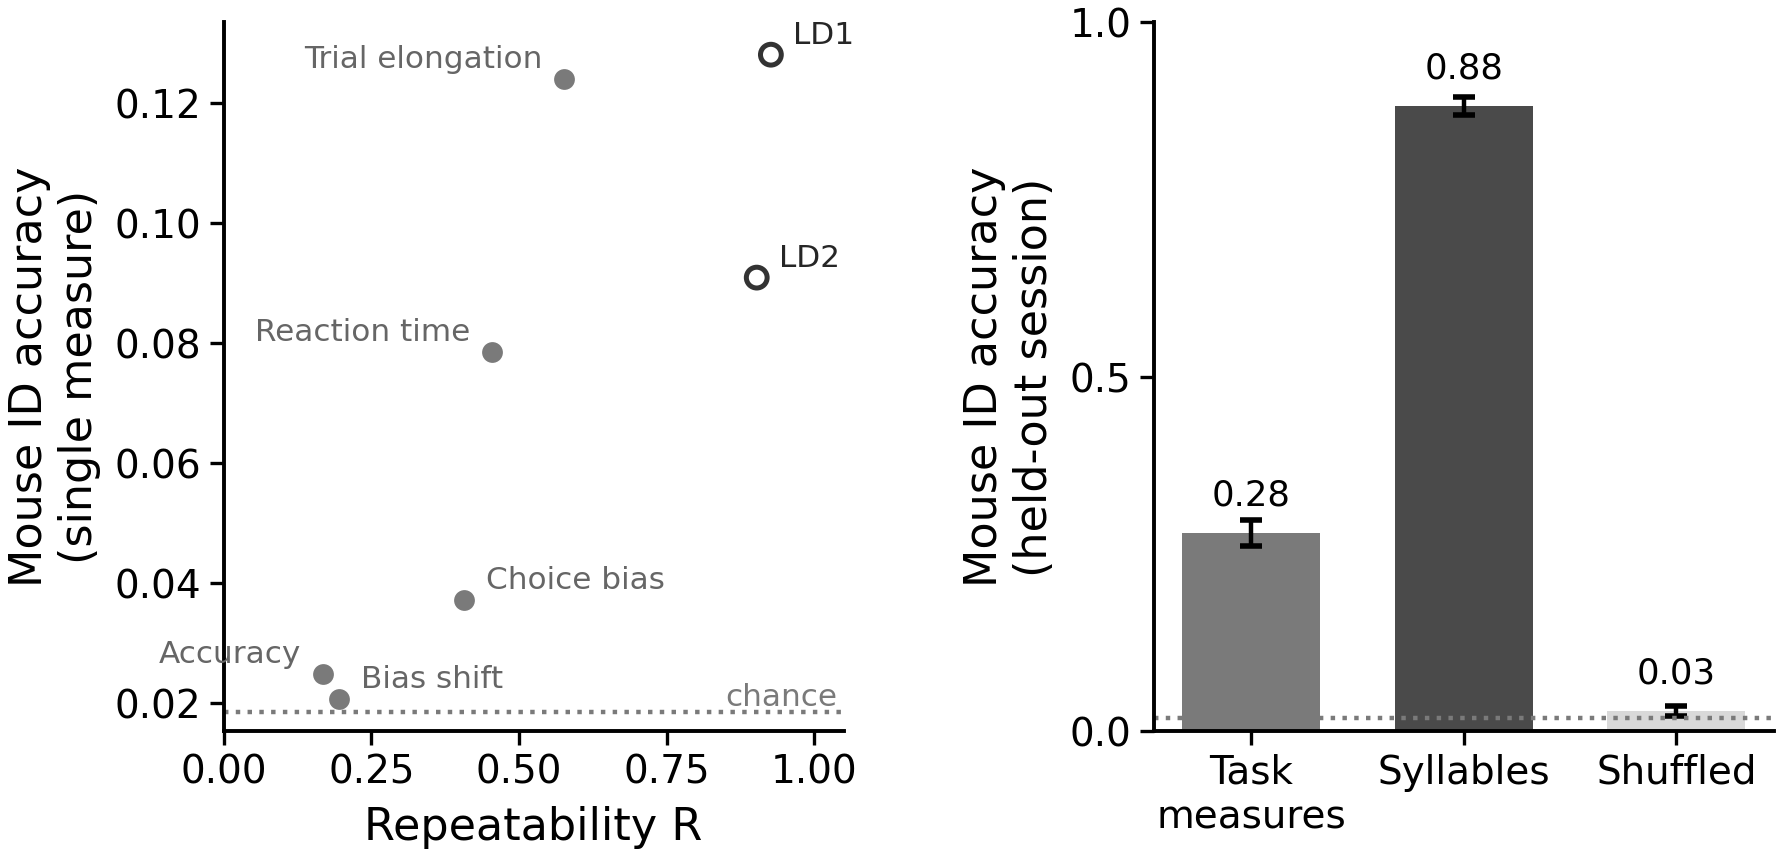

In [9]:
def draw_D(fig, spec):
    ax = fig.add_subplot(spec)
    task, circ = D_TAB[~D_TAB['circular']], D_TAB[D_TAB['circular']]
    ax.scatter(task['R'], task['accuracy'], s=14, color=ps.NEUTRAL, lw=0, zorder=3)
    ax.scatter(circ['R'], circ['accuracy'], s=14, facecolors='none', edgecolors='0.2',
               lw=0.9, zorder=4)
    # labels alternate right / left of their point (sorted by accuracy), so near-ties do not stack
    for k, (nm, row) in enumerate(D_TAB.sort_values('accuracy').iterrows()):
        right = k % 2 == 0
        ax.annotate(row['label'], (row['R'], row['accuracy']), textcoords='offset points',
                    xytext=(4 if right else -4, 1), ha='left' if right else 'right', va='bottom',
                    fontsize=plt.rcParams['font.size'] * 0.7, color='0.15' if row['circular'] else '0.4')
    ax.axhline(CHANCE, color=ps.NEUTRAL, ls=':', lw=0.8)
    ax.text(0.99, CHANCE, 'chance', transform=ax.get_yaxis_transform(), va='bottom', ha='right',
            fontsize=plt.rcParams['font.size'] * 0.7, color=ps.NEUTRAL)
    ax.set_xlabel('Repeatability R'); ax.set_ylabel('Mouse ID accuracy\n(single measure)')
    ax.set_xlim(0, 1.05)
    return [ax]

def draw_E(fig, spec):
    ax = fig.add_subplot(spec)
    names = list(E_RES)
    vals = [E_RES[k].mean() for k in names]; errs = [E_RES[k].std() for k in names]
    ax.bar(range(len(names)), vals, yerr=errs, width=0.65, color=[ps.NEUTRAL, '#4a4a4a', '#D9D9D9'],
           error_kw=dict(lw=0.8, capsize=2))
    for i, v in enumerate(vals):
        ax.text(i, v + 0.03, f'{v:.2f}', ha='center', va='bottom', fontsize=plt.rcParams['font.size'] * 0.8)
    ax.axhline(CHANCE_E, color=ps.NEUTRAL, ls=':', lw=0.8)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(['Task\nmeasures', 'Syllables', 'Shuffled'])
    ax.set_ylim(0, 1); ax.set_yticks([0, 0.5, 1]); ax.set_ylabel('Mouse ID accuracy\n(held-out session)')
    return [ax]

fig = plt.figure(figsize=(5, 2.3))
g = fig.add_gridspec(1, 2, wspace=0.5)
draw_D(fig, g[0]); draw_E(fig, g[1]); plt.show()

## The assembled figure

180 mm wide, same type size everywhere (drawn by the `draw_*` functions above, nothing rescaled). Top row: A (LD1–LD2 plane) and B (syllables along LD1). Bottom: C (trial-level correlates, 2 × 3) on the left; D above E on the right. Writes `figure_generation/figures/fig_ld1.pdf` (for LaTeX; undated so the `\includegraphics` line never changes) and a dated SVG.

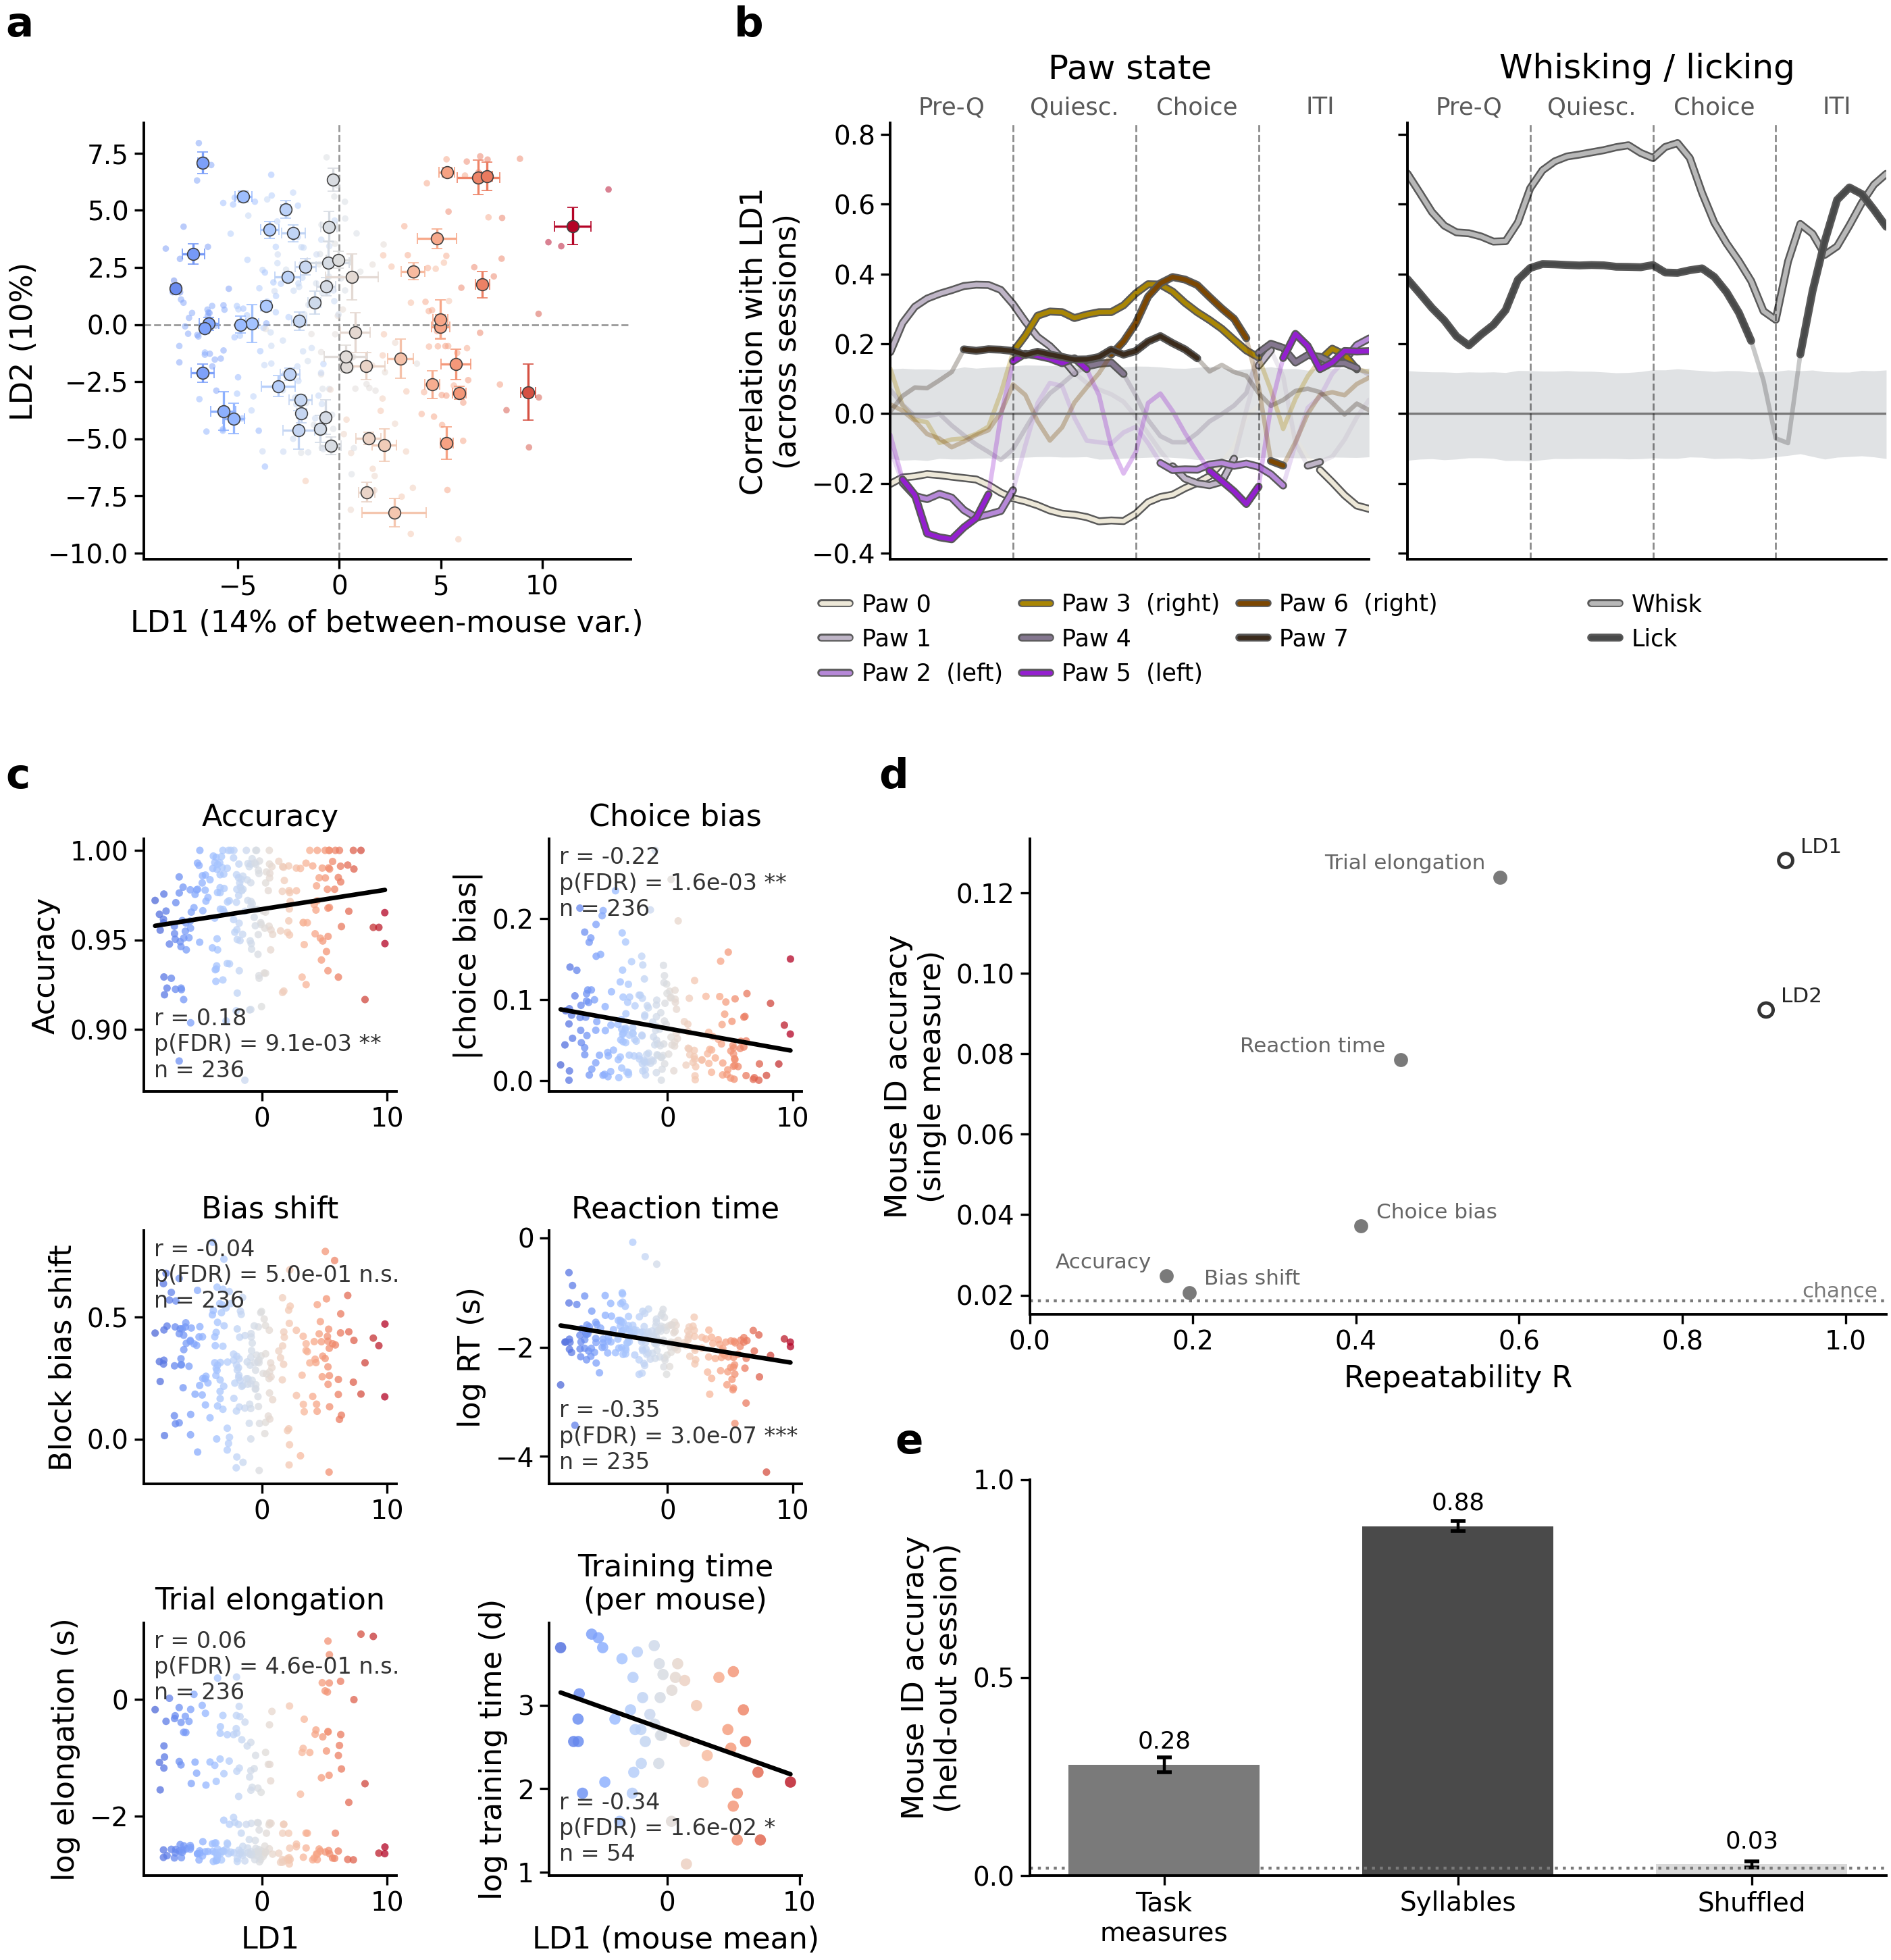

wrote figure_generation/figures/fig_ld1_08-10-2026.svg


wrote figure_generation/figures/fig_ld1.pdf


In [10]:
from datetime import date
import fig_layout as fl          # shared margins, left-edge alignment and panel letters (figure_generation/fig_layout.py)
FIG_H = 6.9

fig = plt.figure(figsize=(fl.FIG_WIDTH, FIG_H))
# top row short, so a and b are a bit wider than tall
outer = fig.add_gridspec(2, 1, height_ratios=[1.85, 4.4], hspace=fl.ROW_HSPACE, **fl.MARGINS)
row1 = outer[0].subgridspec(1, 2, width_ratios=[2.3, 4.7], wspace=0.35)
row2 = outer[1].subgridspec(1, 2, width_ratios=[3.0, 3.9], wspace=0.3)
right2 = row2[1].subgridspec(2, 1, height_ratios=[1.2, 1], hspace=fl.ROW_HSPACE)
panels = {'A': draw_A(fig, row1[0], square=False), 'B': draw_B(fig, row1[1]), 'C': draw_C(fig, row2[0]),
          'D': draw_D(fig, right2[0]), 'E': draw_E(fig, right2[1])}

# a gets b's vertical extent: same bottom (x axes aligned) and same height (y axes the same length)
pa, pb = panels['A'][0].get_position(), panels['B'][0].get_position()
panels['A'][0].set_position([pa.x0, pb.y0, pa.width, pb.height])
# left column (a, c): one left edge
fl.align_left(fig, panels['A'] + [panels['C'][i] for i in (0, 2, 4)])
fl.place_letters(fig, panels, rows=['AB', 'CD', 'E'], left='AC')
plt.show()

OUT_DIR = PI / 'figure_generation' / 'figures'
OUT_DIR.mkdir(exist_ok=True)
for path in [OUT_DIR / f"{FIG}_{date.today().strftime('%d-%m-%Y')}.svg", OUT_DIR / f'{FIG}.pdf']:
    fig.savefig(path)
    print('wrote', path.relative_to(PI))